# Seleção do modelo — experimentos, hipóteses e ajuste com Optuna

## Objetivo
Comparar quatro algoritmos nas mesmas janelas temporais do notebook 04, investigar o benefício das variáveis candidatas e congelar uma configuração para a avaliação final do notebook 06.

**Sequência:** comparação inicial com 18 entradas físicas → grupos de variáveis nos dois melhores candidatos → preço original versus logaritmo na combinação escolhida → Optuna limitado → escolha documentada. O teste final e os exemplos futuros não participam desses experimentos.

**Critério principal:** MAE médio das três janelas, sempre na escala original de preço. Entre combinações com erro até 1% acima do menor MAE observado, preferimos menos colunas; depois, menor MAE. Essa margem operacional foi definida antes da execução para evitar maior dependência de dados por um ganho muito pequeno; não é um teste de significância estatística.

**Recursos:** no máximo duas threads numéricas, experimentos sequenciais, árvores com tamanho limitado e Optuna com até oito tentativas ou 90 segundos. Há um orçamento orientativo de cinco minutos de ajuste e previsão, sem contar pausas de leitura; um ajuste já iniciado pode terminar após o limite. O tempo é verificado entre etapas, não é uma interrupção rígida de processos.

**Limitações:** a EDA considerou o histórico completo e estas janelas serão reutilizadas para várias escolhas. Por isso, o melhor resultado de validação pode ser otimista e exige a avaliação final separada. Datas e definições dos indicadores demográficos permanecem pendentes: seu uso aqui é experimental, não certificação de disponibilidade em produção.

**Execução:** use o Python da `.venv` e execute em ordem. Os resultados sobrescrevem os relatórios desta etapa; os arquivos de split e os dados não são modificados. Nenhum modelo é ajustado no teste.

In [1]:
# Limita o paralelismo e prepara o ambiente de experimentação.
import os
for nome_limite in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ[nome_limite] = "2"

from pathlib import Path
from time import perf_counter
import gc
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import sklearn
import optuna
from IPython.display import display as exibir
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from threadpoolctl import threadpool_limits

PASTA_PROJETO = Path.cwd()
if not (PASTA_PROJETO / "data" / "processed").is_dir():
    PASTA_PROJETO = PASTA_PROJETO.parent
PASTA_DADOS = PASTA_PROJETO / "data" / "processed"
PASTA_RESULTADOS = PASTA_PROJETO / "reports" / "metrics"
PASTA_GRAFICOS = PASTA_PROJETO / "reports" / "figures"
PASTA_ARTEFATOS = PASTA_PROJETO / "artifacts"
for pasta in [PASTA_RESULTADOS, PASTA_GRAFICOS, PASTA_ARTEFATOS]:
    pasta.mkdir(parents=True, exist_ok=True)

SEMENTE = 42
LIMITE_THREADS = 2
MAX_TENTATIVAS = 8
TEMPO_OPTUNA_SEGUNDOS = 90
TEMPO_EXPERIMENTOS_SEGUNDOS = 300
MARGEM_SIMPLICIDADE = 0.01
MIN_RAM_LIVRE_GIB = 1.0
optuna.logging.set_verbosity(optuna.logging.WARNING)

exibir(pd.DataFrame({
    "recurso": ["RAM disponível (GiB)", "Threads", "Experimentos simultâneos",
                "Tentativas máximas Optuna", "Tempo máximo da busca (s)"],
    "valor": [round(psutil.virtual_memory().available / 2**30, 2), LIMITE_THREADS, 1,
              MAX_TENTATIVAS, TEMPO_OPTUNA_SEGUNDOS],
}))

C:\Users\Pichau\Desktop\Desafio Técnico GenAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,recurso,valor
0,RAM disponível (GiB),5.2
1,Threads,2.0
2,Experimentos simultâneos,1.0
3,Tentativas máximas Optuna,8.0
4,Tempo máximo da busca (s),90.0


**O que o resultado mostra**

A configuração limita paralelismo e tamanho da busca. A RAM disponível é medida no momento da execução e pode variar com outros programas.

**Por que fizemos esta análise e o que decidimos**

Não vamos treinar todas as combinações de colunas em todos os algoritmos. A exploração será gradual e reutilizará resultados idênticos na mesma execução. Antes de cada ajuste, verificamos se há pelo menos 1 GiB livre; essa checagem não equivale a um limite rígido de memória.

O limite global de 300 segundos contabiliza os ajustes e as previsões, sem contar pausas de leitura entre células. A verificação ocorre antes de iniciar o próximo ajuste; um ajuste em andamento pode ultrapassar o limite. Ridge usa matriz esparsa; os modelos de árvores usam matriz densa, pequena para este conjunto de dados.

## 1. Reutilizando as mesmas vendas de treino e validação

A comparação só é coerente se os candidatos forem avaliados nas mesmas vendas. Conferimos os hashes registrados no notebook 04 e reconstruímos os índices a partir dos manifestos, sem gerar novo split.

In [2]:
# Confere fontes e reconstrução das três janelas, sem acessar preços do teste para métricas.
protocolo_baseline = json.loads((PASTA_RESULTADOS / "baseline_protocolo.json").read_text(encoding="utf-8"))
contrato = json.loads((PASTA_DADOS / "contrato_features.json").read_text(encoding="utf-8"))
for nome_arquivo, hash_esperado in protocolo_baseline["source_sha256"].items():
    assert hashlib.sha256((PASTA_DADOS / nome_arquivo).read_bytes()).hexdigest() == hash_esperado, nome_arquivo

todas_variaveis = pd.read_csv(PASTA_DADOS / "features_historico.csv", dtype={"zipcode": "string"})
identificacao = pd.read_csv(PASTA_DADOS / "identificacao_alvo_historico.csv", dtype={"id": "string"})
manifesto_split = pd.read_csv(PASTA_DADOS / "split_manifest.csv", dtype={"id": "string"})
manifesto_cv = pd.read_csv(PASTA_DADOS / "cv_manifest.csv")
assert todas_variaveis.columns.tolist() == contrato["colunas_saida_ordenadas"]
assert identificacao["linha_origem"].tolist() == list(range(len(todas_variaveis)))
assert manifesto_split["source_row"].tolist() == identificacao["linha_origem"].tolist()
assert manifesto_split["id"].equals(identificacao["id"])
assert pd.to_datetime(manifesto_split["date"]).equals(pd.to_datetime(identificacao["date"], format="%Y%m%dT%H%M%S"))
assert manifesto_split["partition"].value_counts().to_dict() == protocolo_baseline["split_counts"]
assert set(manifesto_cv["fold"]) == {1, 2, 3}
assert set(manifesto_cv["role"]) == {"train", "validation", "excluded_overlap"}
assert not manifesto_cv.duplicated(["fold", "source_row"]).any()

linhas_permitidas = manifesto_split.loc[manifesto_split["partition"].eq("train_validation"), "source_row"]
linhas_teste = set(manifesto_split.loc[manifesto_split["partition"].eq("test"), "source_row"])
ids_teste = set(manifesto_split.loc[manifesto_split["partition"].eq("test"), "id"])
assert set(manifesto_cv["source_row"]) <= set(linhas_permitidas)
entradas = todas_variaveis.loc[linhas_permitidas].copy()
precos = identificacao.set_index("linha_origem").loc[linhas_permitidas, "price"]
metadados = identificacao.set_index("linha_origem").loc[linhas_permitidas, ["id", "date"]].copy()
metadados["date"] = pd.to_datetime(metadados["date"], format="%Y%m%dT%H%M%S")
del todas_variaveis, identificacao

particoes = []
for janela in sorted(manifesto_cv["fold"].unique()):
    indices_treino = manifesto_cv.loc[manifesto_cv["fold"].eq(janela) & manifesto_cv["role"].eq("train"), "source_row"].to_numpy()
    indices_validacao = manifesto_cv.loc[manifesto_cv["fold"].eq(janela) & manifesto_cv["role"].eq("validation"), "source_row"].to_numpy()
    assert metadados.loc[indices_treino, "date"].max() < metadados.loc[indices_validacao, "date"].min()
    assert not set(metadados.loc[indices_treino, "id"]) & set(metadados.loc[indices_validacao, "id"])
    assert not set(metadados.loc[np.r_[indices_treino, indices_validacao], "id"]) & ids_teste
    particoes.append((indices_treino, indices_validacao))
assert not manifesto_cv.query("role == 'validation'")["source_row"].duplicated().any()
grupos = contrato["grupos_candidatos"]
assert grupos["fisicas_originais"] == protocolo_baseline["features"]
exibir(pd.DataFrame([
    {"janela": numero, "treino": len(treino), "validacao": len(validacao)}
    for numero, (treino, validacao) in enumerate(particoes, start=1)
]))

,janela,treino,validacao
0,1,11241,2392
1,2,13626,1626
2,3,15235,1917


**O que o resultado mostra**

As janelas têm 11.241/2.392, 13.626/1.626 e 15.235/1.917 registros de treino/validação. Os hashes, datas e IDs são conferidos antes dos experimentos.

**Por que fizemos esta análise e o que decidimos**

Se a fonte ou as partições mudarem, é necessário revisar a comparação. Nenhum ID do teste pode aparecer nas janelas. Os preços usados daqui em diante pertencem apenas ao conjunto de treino e validação; a tabela completa foi descartada da memória após selecionar essa parcela.

## 2. Quatro candidatos e regras de comparação

**Ridge:** referência linear regularizada, já avaliada no notebook 04.

**Random Forest:** combina árvores treinadas em amostras dos dados.

**Extra Trees:** combina árvores com maior aleatoriedade na construção das divisões.

**HistGradientBoosting:** combina árvores de forma sequencial e usa histogramas para limitar o custo.

Os candidatos recebem as mesmas entradas e as mesmas janelas. Para árvores, não aplicamos normalização; para Ridge, preservamos o pipeline do baseline. O preenchimento e a codificação de CEP são ajustados somente no treino. O boosting não usará parada antecipada com uma divisão aleatória interna; controlamos seu tamanho por número de iterações. Referência: [HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html).

In [3]:
# Define modelos pequenos e constrói um pipeline novo para cada avaliação.
parametros_iniciais = {
    "Ridge": {"alpha": 1.0, "solver": "lsqr", "tol": 1e-6},
    "Random Forest": {"n_estimators": 80, "max_depth": 14, "min_samples_leaf": 3, "max_features": 0.8},
    "Extra Trees": {"n_estimators": 100, "max_depth": 18, "min_samples_leaf": 2, "max_features": 1.0},
    "HistGradientBoosting": {"max_iter": 160, "learning_rate": 0.08, "max_leaf_nodes": 31,
                            "min_samples_leaf": 20, "l2_regularization": 1.0, "max_bins": 127},
}

def construir_pipeline(nome_modelo, colunas, parametros, usar_log=False):
    numericas = [coluna for coluna in colunas if coluna != "zipcode"]
    etapas_numericas = [("imputacao", SimpleImputer(strategy="median", keep_empty_features=True))]
    if nome_modelo == "Ridge":
        etapas_numericas.append(("escala", StandardScaler()))
    # Matrizes densas são pequenas aqui e evitam custo extra nas florestas.
    usar_esparsa = nome_modelo == "Ridge"
    preparacao = ColumnTransformer([
        ("numericas", Pipeline(etapas_numericas), numericas),
        ("categoricas", Pipeline([
            ("imputacao", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
            ("codificacao", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=usar_esparsa)),
        ]), ["zipcode"]),
    ], sparse_threshold=1.0 if usar_esparsa else 0.0, n_jobs=1)
    if nome_modelo == "Ridge":
        estimador = Ridge(**parametros)
    elif nome_modelo == "Random Forest":
        estimador = RandomForestRegressor(**parametros, random_state=SEMENTE, n_jobs=LIMITE_THREADS)
    elif nome_modelo == "Extra Trees":
        estimador = ExtraTreesRegressor(**parametros, random_state=SEMENTE, n_jobs=LIMITE_THREADS)
    else:
        assert nome_modelo == "HistGradientBoosting"
        estimador = HistGradientBoostingRegressor(**parametros, random_state=SEMENTE, early_stopping=False)
    pipeline = Pipeline([("preparacao", preparacao), ("modelo", estimador)])
    if usar_log:
        return TransformedTargetRegressor(regressor=pipeline, func=np.log1p, inverse_func=np.expm1)
    return pipeline

exibir(pd.DataFrame([
    {"modelo": nome, "configuracao": json.dumps(parametros, ensure_ascii=False)}
    for nome, parametros in parametros_iniciais.items()
]))

,modelo,configuracao
0,Ridge,"{""alpha"": 1.0, ""solver"": ""lsqr"", ""tol"": 1e-06}"
1,Random Forest,"{""n_estimators"": 80, ""max_depth"": 14, ""min_sam..."
2,Extra Trees,"{""n_estimators"": 100, ""max_depth"": 18, ""min_sa..."
3,HistGradientBoosting,"{""max_iter"": 160, ""learning_rate"": 0.08, ""max_..."


**O que o resultado mostra**

A tabela registra as configurações iniciais, sem busca de melhores valores. São quatro algoritmos, não quatro ajustes: cada candidato é avaliado em três janelas.

**Por que fizemos esta análise e o que decidimos**

Ridge será reaproveitado do notebook 04 se os parâmetros e resultados conferirem. Os demais serão treinados agora. O boosting usa matriz densa pequena; as demais preparações usam matriz esparsa. Limitar profundidade, folhas e número de árvores controla a primeira comparação.

**Hipótese**

Os modelos de árvores podem representar relações não lineares entre área, localização e preço. Isso será confrontado com o desempenho da referência linear, não assumido antecipadamente.

In [4]:
# Centraliza avaliação, registro e reaproveitamento de combinações idênticas.
experimentos = {}
configuracoes = {}
contagem_ajustes = 0
processo = psutil.Process()
memoria_observada_mib = processo.memory_info().rss / 2**20
inicio_experimentos = perf_counter()
segundos_ajustes = 0.0

def chave_experimento(nome, grupo, parametros, usar_log):
    return json.dumps({"modelo": nome, "grupo": grupo, "parametros": parametros,
                       "log_alvo": usar_log}, sort_keys=True)

def avaliar_configuracao(nome, grupo, parametros, usar_log=False, tentativa=None):
    global contagem_ajustes, memoria_observada_mib, segundos_ajustes
    chave = chave_experimento(nome, grupo, parametros, usar_log)
    if chave in experimentos:
        return experimentos[chave]
    colunas = grupos[grupo]
    resultados_janelas = []
    previsoes_janelas = []
    inicio_configuracao = perf_counter()
    for janela, (treino, validacao) in enumerate(particoes, start=1):
        if psutil.virtual_memory().available / 2**30 < MIN_RAM_LIVRE_GIB:
            raise RuntimeError("Pouca RAM livre: feche outros programas antes de continuar.")
        if segundos_ajustes > TEMPO_EXPERIMENTOS_SEGUNDOS:
            if tentativa is not None:
                raise optuna.TrialPruned("Orçamento total de tempo atingido.")
            raise TimeoutError("Orçamento atingido entre ajustes; resultados anteriores estão na memória.")
        modelo = construir_pipeline(nome, colunas, parametros, usar_log)
        inicio_ajuste = perf_counter()
        with threadpool_limits(limits=LIMITE_THREADS):
            modelo.fit(entradas.loc[treino, colunas], precos.loc[treino])
            previsto = modelo.predict(entradas.loc[validacao, colunas])
        duracao_ajuste = perf_counter() - inicio_ajuste
        segundos_ajustes += duracao_ajuste
        contagem_ajustes += 1
        assert np.isfinite(previsto).all()
        assert not set(validacao) & linhas_teste
        mae = mean_absolute_error(precos.loc[validacao], previsto)
        resultados_janelas.append({
            "janela": janela, "mae": mae,
            "rmse": root_mean_squared_error(precos.loc[validacao], previsto),
            "r2": r2_score(precos.loc[validacao], previsto),
            "previsoes_nao_positivas": int((previsto <= 0).sum()),
            "segundos": duracao_ajuste,
        })
        previsoes_janelas.append(pd.DataFrame({
            "source_row": validacao, "janela": janela,
            "preco_real": precos.loc[validacao].to_numpy(), "preco_previsto": previsto,
        }))
        memoria_observada_mib = max(memoria_observada_mib, processo.memory_info().rss / 2**20)
        del modelo
        if tentativa is not None:
            tentativa.report(float(np.mean([linha["mae"] for linha in resultados_janelas])), step=janela)
            if tentativa.should_prune():
                raise optuna.TrialPruned()
    resultado = {
        "modelo": nome, "grupo": grupo, "log_alvo": usar_log,
        "parametros": dict(parametros), "n_colunas": len(colunas),
        "mae_medio": float(np.mean([linha["mae"] for linha in resultados_janelas])),
        "mae_desvio": float(np.std([linha["mae"] for linha in resultados_janelas], ddof=1)),
        "rmse_medio": float(np.mean([linha["rmse"] for linha in resultados_janelas])),
        "r2_medio": float(np.mean([linha["r2"] for linha in resultados_janelas])),
        "nao_positivas": int(sum(linha["previsoes_nao_positivas"] for linha in resultados_janelas)),
        "segundos": perf_counter() - inicio_configuracao,
        "janelas": resultados_janelas,
        "previsoes": pd.concat(previsoes_janelas, ignore_index=True),
        "origem": "execucao_atual",
    }
    experimentos[chave] = resultado
    configuracoes[chave] = {"modelo": nome, "grupo": grupo, "parametros": dict(parametros), "log_alvo": usar_log}
    gc.collect()
    print(f"{nome} | {grupo} | log={usar_log} | MAE={resultado['mae_medio']:.2f}", flush=True)
    return resultado

def resumir(lista_resultados):
    campos = ["modelo", "grupo", "log_alvo", "n_colunas", "mae_medio", "mae_desvio",
              "rmse_medio", "r2_medio", "nao_positivas", "segundos", "origem"]
    return pd.DataFrame([{campo: resultado[campo] for campo in campos} for resultado in lista_resultados])

def escolher_simples(lista_resultados):
    limite = min(resultado["mae_medio"] for resultado in lista_resultados) * (1 + MARGEM_SIMPLICIDADE)
    elegiveis = [resultado for resultado in lista_resultados if resultado["mae_medio"] <= limite]
    return min(elegiveis, key=lambda resultado: (resultado["n_colunas"], resultado["mae_medio"],
                                                resultado["modelo"], resultado["log_alvo"]))

# Reaproveita Ridge somente após conferir parâmetros, partições e métricas.
assert sklearn.__version__ == protocolo_baseline["resources"]["scikit_learn"]
assert parametros_iniciais["Ridge"]["alpha"] == protocolo_baseline["baseline_parameters"]["ridge_alpha"]
assert parametros_iniciais["Ridge"]["tol"] == protocolo_baseline["baseline_parameters"]["ridge_tol"]
assert parametros_iniciais["Ridge"]["solver"] == protocolo_baseline["baseline_parameters"]["ridge_solver"]
metricas_ridge = pd.read_csv(PASTA_RESULTADOS / "baseline_cv_resultados.csv").query("modelo == 'Ridge'").sort_values("janela")
previsoes_ridge = pd.read_csv(PASTA_RESULTADOS / "baseline_cv_previsoes.csv").query("modelo == 'Ridge'").copy()
assert len(metricas_ridge) == 3
for janela, (treino, validacao) in enumerate(particoes, start=1):
    previsoes_janela = previsoes_ridge.loc[previsoes_ridge["janela"].eq(janela)].set_index("source_row")
    assert set(previsoes_janela.index) == set(validacao) and previsoes_janela.index.is_unique
    assert metricas_ridge.loc[metricas_ridge["janela"].eq(janela), "n_treino"].iloc[0] == len(treino)
    np.testing.assert_allclose(previsoes_janela.loc[validacao, "preco_real"], precos.loc[validacao])
    np.testing.assert_allclose(mean_absolute_error(precos.loc[validacao], previsoes_janela.loc[validacao, "preco_previsto"]),
                               metricas_ridge.loc[metricas_ridge["janela"].eq(janela), "mae"].iloc[0])
chave_ridge = chave_experimento("Ridge", "fisicas_originais", parametros_iniciais["Ridge"], False)
experimentos[chave_ridge] = {
    "modelo": "Ridge", "grupo": "fisicas_originais", "log_alvo": False,
    "parametros": parametros_iniciais["Ridge"], "n_colunas": 18,
    "mae_medio": float(metricas_ridge["mae"].mean()), "mae_desvio": float(metricas_ridge["mae"].std()),
    "rmse_medio": float(metricas_ridge["rmse"].mean()), "r2_medio": float(metricas_ridge["r2"].mean()),
    "nao_positivas": int(metricas_ridge["previsoes_nao_positivas"].sum()),
    "segundos": float(metricas_ridge["segundos"].sum()),
    "janelas": metricas_ridge.drop(columns="modelo").to_dict(orient="records"),
    "previsoes": previsoes_ridge.drop(columns="modelo"), "origem": "notebook_04",
}
configuracoes[chave_ridge] = {"modelo": "Ridge", "grupo": "fisicas_originais",
                             "parametros": parametros_iniciais["Ridge"], "log_alvo": False}
print("Ridge conferido: três ajustes anteriores reaproveitados.")

Ridge conferido: três ajustes anteriores reaproveitados.


**O que o resultado mostra**

A função usa as mesmas três janelas para cada configuração, recria o pipeline em cada treino e guarda métricas e previsões apenas de validação. Ridge foi conferido contra os preços e as janelas salvas.

**Por que fizemos esta análise e o que decidimos**

O reaproveitamento evita três ajustes repetidos. A chave de cache inclui algoritmo, grupo, parâmetros e transformação do alvo. A verificação de memória e tempo ocorre entre ajustes; o modelo em andamento não é interrompido abruptamente.

## 3. Comparação inicial dos quatro algoritmos

Esta fase usa apenas as 18 características físicas originais e o preço sem transformação. É a comparação mais direta com o baseline. Os tempos de Ridge vêm da execução anterior e não devem ser interpretados como um benchmark rigoroso contra os tempos desta sessão.

In [5]:
# Compara os quatro candidatos com as mesmas entradas físicas.
resultados_iniciais = []
for nome_modelo, parametros in parametros_iniciais.items():
    resultados_iniciais.append(avaliar_configuracao(nome_modelo, "fisicas_originais", parametros))
comparacao_inicial = resumir(resultados_iniciais).sort_values("mae_medio")
comparacao_inicial.to_csv(PASTA_RESULTADOS / "selecao_comparacao_inicial.csv", index=False)
melhores_modelos = comparacao_inicial["modelo"].head(2).tolist()
exibir(comparacao_inicial.round(3))

Random Forest | fisicas_originais | log=False | MAE=69859.88


Extra Trees | fisicas_originais | log=False | MAE=67364.74


HistGradientBoosting | fisicas_originais | log=False | MAE=65668.25


,modelo,grupo,log_alvo,n_colunas,mae_medio,mae_desvio,rmse_medio,r2_medio,nao_positivas,segundos,origem
3,HistGradientBoosting,fisicas_originais,False,18,65668.246,3770.770,115895.154,0.891,0,3.216,execucao_atual
2,Extra Trees,fisicas_originais,False,18,67364.740,1960.559,118659.444,0.886,0,9.664,execucao_atual
1,Random Forest,fisicas_originais,False,18,69859.883,1829.382,128885.203,0.866,0,7.280,execucao_atual
0,Ridge,fisicas_originais,False,18,97344.711,922.200,153417.307,0.811,20,0.269,notebook_04


**O que o resultado mostra**

A tabela ordena os quatro candidatos pelo MAE médio. O desvio entre janelas informa estabilidade temporal e as previsões não positivas mostram um comportamento incompatível com preço de venda.

**Por que fizemos esta análise e o que decidimos**

Selecionamos os dois menores MAEs para investigar features com um orçamento reduzido. Isso não prova que os demais algoritmos nunca melhorariam com outro ajuste; limita o alcance da busca atual.

**Hipótese**

Se os modelos de árvores reduzirem o erro em relação a Ridge, isso sustenta seu uso como candidatos para relações mais flexíveis. A conclusão fica restrita às configurações e períodos avaliados.

**Resultado desta execução:** HistGradientBoosting teve MAE de 65.668; Extra Trees, 67.365; Random Forest, 69.860; e Ridge, 97.345. São valores na mesma unidade do preço, não percentuais. O boosting e o Extra Trees seguem para a comparação de variáveis. Ridge produziu 20 previsões não positivas; os três modelos de árvores não produziram nenhuma nessas validações. Isso ajuda a identificar comportamentos inadequados, mas não garante que eles nunca ocorrerão em novos dados.

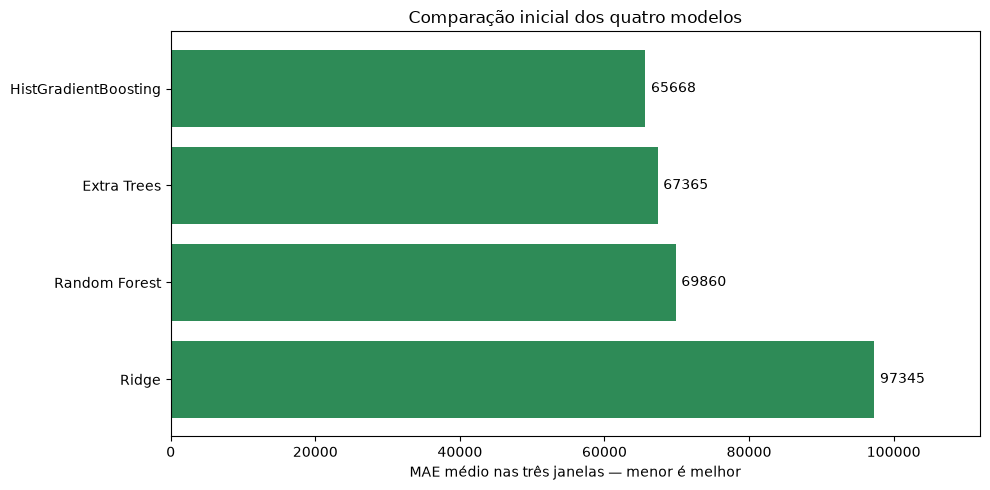

In [6]:
# Mostra o MAE inicial sem linhas de grade e com valores legíveis.
%matplotlib inline
figura, eixo = plt.subplots(figsize=(10, 5))
grafico_inicial = comparacao_inicial.sort_values("mae_medio", ascending=False)
barras = eixo.barh(grafico_inicial["modelo"], grafico_inicial["mae_medio"], color="#2E8B57")
eixo.bar_label(barras, fmt="%.0f", padding=4)
eixo.set(xlabel="MAE médio nas três janelas — menor é melhor", title="Comparação inicial dos quatro modelos")
eixo.set_xlim(0, grafico_inicial["mae_medio"].max() * 1.15)
eixo.grid(False)
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "selecao_modelos_iniciais.png", dpi=150)
plt.show()

**O que o resultado mostra**

Cada barra representa o erro absoluto médio de um algoritmo, na unidade original do preço. Não é percentual de erro nem erro máximo.

**Por que fizemos esta análise e o que decidimos**

O gráfico resume a comparação, enquanto a tabela anterior preserva variação, RMSE e custo. Uma barra menor identifica melhor resultado de validação nesta configuração, não desempenho garantido em outras épocas.

**Como ler:** a barra menor corresponde ao boosting. Em média entre os três períodos, seu erro absoluto foi cerca de 31.677 unidades de preço menor que o do Ridge inicial. A comparação considera configurações pequenas e fixas: não demonstra que um algoritmo sempre será superior aos demais.

## 4. Investigando as features por grupos

Nos dois melhores candidatos, com parâmetros fixos, compararemos: 18 físicas; 25 físicas com derivadas; 50 com demografia sem `hous_val_amt`; e todas as 51 candidatas.

A comparação 18→25 investiga o grupo das derivadas. A comparação 25→50 investiga os demais indicadores demográficos. A comparação 50→51 isola a adição de `hous_val_amt`, mantendo as demais entradas. É uma investigação offline, sujeita à disponibilidade temporal dos indicadores. Um ganho estatístico não resolve essa dúvida de origem.

In [7]:
# Compara grupos nos dois melhores modelos e reaproveita a configuração inicial.
resultados_features = []
for nome_modelo in melhores_modelos:
    for grupo in grupos:
        resultados_features.append(avaliar_configuracao(nome_modelo, grupo, parametros_iniciais[nome_modelo]))
comparacao_features = resumir(resultados_features)
comparacao_features.to_csv(PASTA_RESULTADOS / "selecao_features.csv", index=False)
escolha_features = escolher_simples(resultados_features)
exibir(comparacao_features.sort_values(["modelo", "mae_medio"]).round(3))

HistGradientBoosting | fisicas_com_derivadas | log=False | MAE=65320.32


HistGradientBoosting | fisicas_demografia_sem_hous_val_amt | log=False | MAE=63646.12


HistGradientBoosting | todas_candidatas | log=False | MAE=63808.60


Extra Trees | fisicas_com_derivadas | log=False | MAE=67637.20


Extra Trees | fisicas_demografia_sem_hous_val_amt | log=False | MAE=66132.32


Extra Trees | todas_candidatas | log=False | MAE=65731.93


,modelo,grupo,log_alvo,n_colunas,mae_medio,mae_desvio,rmse_medio,r2_medio,nao_positivas,segundos,origem
7,Extra Trees,todas_candidatas,False,51,65731.925,1915.723,117421.841,0.889,0,17.889,execucao_atual
6,Extra Trees,fisicas_demografia_sem_hous_val_amt,False,50,66132.317,1882.988,118039.380,0.888,0,17.856,execucao_atual
4,Extra Trees,fisicas_originais,False,18,67364.740,1960.559,118659.444,0.886,0,9.664,execucao_atual
5,Extra Trees,fisicas_com_derivadas,False,25,67637.198,1988.145,120044.207,0.884,0,13.850,execucao_atual
2,HistGradientBoosting,fisicas_demografia_sem_hous_val_amt,False,50,63646.117,3327.548,113821.557,0.895,0,4.161,execucao_atual
3,HistGradientBoosting,todas_candidatas,False,51,63808.602,3392.007,113478.654,0.895,0,4.184,execucao_atual
1,HistGradientBoosting,fisicas_com_derivadas,False,25,65320.318,3710.267,117071.264,0.888,0,3.524,execucao_atual
0,HistGradientBoosting,fisicas_originais,False,18,65668.246,3770.770,115895.154,0.891,0,3.216,execucao_atual


**O que o resultado mostra**

As linhas com o mesmo algoritmo usam parâmetros idênticos, mudando apenas o grupo de colunas. As configurações com físicas originais foram reaproveitadas.

**Por que fizemos esta análise e o que decidimos**

Preferimos menos colunas quando o erro está até 1% acima do menor MAE. A seleção é de um conjunto candidato, não um ranking individual das sete derivadas. Não testamos todas as combinações possíveis nem declaramos causalidade.

**Hipótese**

Se as derivadas ou a demografia reduzirem o erro de forma consistente nas janelas, há evidência favorável ao grupo naquele modelo. Se o ganho for pequeno ou instável, o conjunto simples pode ser suficiente.

**Resultado desta execução:** no boosting, as sete derivadas reduziram o MAE de 65.668 para 65.320: melhora pequena, de 0,53%. No Extra Trees, o erro subiu de 67.365 para 67.637. Portanto, a utilidade dessas variáveis depende do algoritmo.

Ao adicionar a demografia sem `hous_val_amt` ao grupo que já contém as derivadas, o MAE caiu para 63.646 no boosting e 66.132 no Extra Trees. Essa mudança melhorou as três janelas nos dois modelos. No boosting, incluir também `hous_val_amt` elevou ligeiramente o MAE para 63.809. Seguimos com boosting e 50 colunas: 18 físicas, sete derivadas e 25 indicadores demográficos. A exclusão dessa coluna decorre desta comparação; não comprova que ela tenha vazamento de informação.

Não testamos demografia sem as sete derivadas. Por isso, não podemos afirmar que todas as 50 colunas sejam necessárias ou que esse seja o menor conjunto possível.

## 5. Preço original versus logaritmo

Avaliamos a configuração escolhida com `log(1 + preço)` no treino e `exp(previsão) − 1` na saída. As métricas continuam na escala original. O logaritmo muda o que o treinamento enfatiza e pode reduzir a influência de vendas muito caras, mas não garante menor MAE ou RMSE. Não aplicamos corte automático de previsões.

In [8]:
# Avalia uma transformação do alvo na combinação selecionada, sem alterar as features.
resultado_log = avaliar_configuracao(
    escolha_features["modelo"], escolha_features["grupo"], escolha_features["parametros"], usar_log=True
)
candidatos_antes_optuna = resultados_features + [resultado_log]
escolha_antes_optuna = escolher_simples(candidatos_antes_optuna)
comparacao_alvo = resumir([escolha_features, resultado_log])
comparacao_alvo.to_csv(PASTA_RESULTADOS / "selecao_transformacao_alvo.csv", index=False)
exibir(comparacao_alvo.round(3))

HistGradientBoosting | fisicas_demografia_sem_hous_val_amt | log=True | MAE=63375.43


,modelo,grupo,log_alvo,n_colunas,mae_medio,mae_desvio,rmse_medio,r2_medio,nao_positivas,segundos,origem
0,HistGradientBoosting,fisicas_demografia_sem_hous_val_amt,False,50,63646.117,3327.548,113821.557,0.895,0,4.161,execucao_atual
1,HistGradientBoosting,fisicas_demografia_sem_hous_val_amt,True,50,63375.434,2932.890,114172.359,0.895,0,4.210,execucao_atual


**O que o resultado mostra**

As duas linhas comparam preço original e logaritmo no mesmo algoritmo e grupo de features. Qualquer diferença de erro é medida depois de retornar à unidade do preço.

**Por que fizemos esta análise e o que decidimos**

A transformação foi testada em uma combinação, para controlar custo. Sua utilidade para outros algoritmos continua não investigada. A escolha anterior à busca considera todos os candidatos de features já avaliados, evitando perder uma alternativa melhor.

**Hipótese**

O logaritmo pode melhorar erros típicos e previsões não positivas, mas também piorar erros de imóveis caros. A tabela compara MAE e RMSE para não tratar a transformação como benefício automático.

**Resultado desta execução:** após desfazer o logaritmo nas previsões, o MAE passou de 63.646 para 63.375, melhora de aproximadamente 0,43%. O RMSE, que dá mais peso aos erros grandes, aumentou ligeiramente de 113.822 para 114.172. Mantivemos o log porque o critério principal previamente definido é MAE. O ganho é pequeno e não permite dizer que todos os tipos de erro melhoraram.

## 6. Optuna com orçamento limitado

Agora ajustamos apenas o algoritmo, o grupo e a transformação escolhidos. O Optuna propõe hiperparâmetros e cada tentativa completa usa as três janelas. Tentativas podem ser interrompidas entre janelas quando pouco promissoras.

Limites: oito tentativas, 90 segundos para a busca e execução sequencial. O `timeout` limita o início de novas tentativas; não interrompe necessariamente um ajuste em andamento. Referência: [Study.optimize](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.study.Study.html).

Se a busca não melhorar o candidato anterior, ele será mantido. Não há obrigação de escolher uma configuração só porque veio do Optuna.

In [9]:
# Busca poucos hiperparâmetros, preservando o candidato anterior como referência.
nome_busca = escolha_antes_optuna["modelo"]
grupo_busca = escolha_antes_optuna["grupo"]
log_busca = escolha_antes_optuna["log_alvo"]

def objetivo(tentativa):
    parametros = dict(parametros_iniciais[nome_busca])
    if nome_busca == "Ridge":
        parametros["alpha"] = tentativa.suggest_float("alpha", 0.01, 100.0, log=True)
    elif nome_busca in ["Random Forest", "Extra Trees"]:
        parametros.update({
            "n_estimators": tentativa.suggest_int("n_estimators", 60, 140, step=20),
            "max_depth": tentativa.suggest_int("max_depth", 8, 20, step=4),
            "min_samples_leaf": tentativa.suggest_int("min_samples_leaf", 1, 6),
            "max_features": tentativa.suggest_float("max_features", 0.6, 1.0),
        })
    else:
        parametros.update({
            "max_iter": tentativa.suggest_int("max_iter", 100, 220, step=40),
            "learning_rate": tentativa.suggest_float("learning_rate", 0.03, 0.12, log=True),
            "max_leaf_nodes": tentativa.suggest_categorical("max_leaf_nodes", [15, 31]),
            "min_samples_leaf": tentativa.suggest_int("min_samples_leaf", 15, 45, step=10),
            "l2_regularization": tentativa.suggest_float("l2_regularization", 0.01, 10.0, log=True),
        })
    resultado = avaliar_configuracao(nome_busca, grupo_busca, parametros, usar_log=log_busca, tentativa=tentativa)
    tentativa.set_user_attr("chave_experimento", chave_experimento(nome_busca, grupo_busca, parametros, log_busca))
    return resultado["mae_medio"]

estudo = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEMENTE, n_startup_trials=4),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1),
)
tempo_restante = max(0.0, TEMPO_EXPERIMENTOS_SEGUNDOS - segundos_ajustes)
if tempo_restante > 0:
    estudo.optimize(objetivo, n_trials=MAX_TENTATIVAS, timeout=min(TEMPO_OPTUNA_SEGUNDOS, tempo_restante),
                    n_jobs=1, gc_after_trial=True, show_progress_bar=False)

tentativas = estudo.trials_dataframe()
tentativas.to_csv(PASTA_RESULTADOS / "selecao_optuna_trials.csv", index=False)
# Considera somente configurações avaliadas nas três janelas.
escolha_final = escolher_simples(list(experimentos.values()))
comparacao_final = resumir([escolha_antes_optuna, escolha_final])
comparacao_final.insert(0, "momento", ["Antes do Optuna", "Configuração final"])
exibir(comparacao_final.round(3))

HistGradientBoosting | fisicas_demografia_sem_hous_val_amt | log=True | MAE=64704.76


HistGradientBoosting | fisicas_demografia_sem_hous_val_amt | log=True | MAE=63518.28


HistGradientBoosting | fisicas_demografia_sem_hous_val_amt | log=True | MAE=63459.86


HistGradientBoosting | fisicas_demografia_sem_hous_val_amt | log=True | MAE=62456.58


HistGradientBoosting | fisicas_demografia_sem_hous_val_amt | log=True | MAE=62736.89


,momento,modelo,grupo,log_alvo,n_colunas,mae_medio,mae_desvio,rmse_medio,r2_medio,nao_positivas,segundos,origem
0,Antes do Optuna,HistGradientBoosting,fisicas_demografia_sem_hous_val_amt,True,50,63375.434,2932.890,114172.359,0.895,0,4.210,execucao_atual
1,Configuração final,HistGradientBoosting,fisicas_demografia_sem_hous_val_amt,True,50,62456.580,2767.183,112160.847,0.899,0,5.572,execucao_atual


**O que o resultado mostra**

A tabela compara a configuração anterior à busca com a escolha final entre todas as configurações completas. Tentativas interrompidas não entram na seleção, porque não têm as três janelas avaliadas.

**Por que fizemos esta análise e o que decidimos**

O orçamento curto torna a busca exploratória, não exaustiva. Como a mesma CV orientou seleção de features e hiperparâmetros, o ganho observado precisa ser confirmado no teste final. Não consultaremos o teste para aumentar tentativas ou mudar a decisão.

**Resultado desta execução:** o Optuna iniciou oito tentativas: cinco completaram as três janelas e três foram interrompidas por desempenho intermediário. A configuração selecionada reduziu o MAE de 63.375 para 62.457, cerca de 1,45% de melhora sobre a referência anterior à busca. Os valores de tentativas interrompidas no CSV são intermediários; não devem ser comparados diretamente com a média das três janelas dos candidatos completos.

## 7. Registro de hipóteses: evidência, alcance e decisão

A tabela abaixo quantifica mudanças relativas entre conjuntos, sempre com o mesmo algoritmo e parâmetros. Valor positivo significa redução do MAE; negativo significa piora. O número de janelas melhoradas mostra consistência, mas três janelas não são um teste de significância.

In [10]:
# Registra resultados pareados das hipóteses de ganho preditivo.
registro_hipoteses = []
transicoes = [
    ("Derivadas acrescentam ganho", "fisicas_originais", "fisicas_com_derivadas"),
    ("Demografia sem valor habitacional acrescenta ganho", "fisicas_com_derivadas", "fisicas_demografia_sem_hous_val_amt"),
    ("hous_val_amt acrescenta ganho incremental", "fisicas_demografia_sem_hous_val_amt", "todas_candidatas"),
]
for nome_modelo in melhores_modelos:
    for hipotese, grupo_base, grupo_novo in transicoes:
        base = experimentos[chave_experimento(nome_modelo, grupo_base, parametros_iniciais[nome_modelo], False)]
        novo = experimentos[chave_experimento(nome_modelo, grupo_novo, parametros_iniciais[nome_modelo], False)]
        ganho = (1 - novo["mae_medio"] / base["mae_medio"]) * 100
        janelas_melhores = sum(novo_j["mae"] < base_j["mae"] for base_j, novo_j in zip(base["janelas"], novo["janelas"]))
        registro_hipoteses.append({
            "hipotese": hipotese, "modelo": nome_modelo,
            "reducao_mae_pct": ganho, "janelas_melhores": janelas_melhores,
            "leitura": "ganho consistente observado" if ganho > 0 and janelas_melhores == 3 else
                       ("ganho médio com variação entre janelas" if ganho > 0 else "ganho médio não observado"),
            "limite": "comparação offline; fonte e período dos indicadores pendentes" if grupo_novo != "fisicas_com_derivadas" else
                      "efeito do grupo, não de cada feature individual",
        })
registro_hipoteses = pd.DataFrame(registro_hipoteses)
registro_hipoteses.to_csv(PASTA_RESULTADOS / "selecao_hipoteses.csv", index=False)
with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
    exibir(registro_hipoteses.round(3))

,hipotese,modelo,reducao_mae_pct,janelas_melhores,leitura,limite
0,Derivadas acrescentam ganho,HistGradientBoosting,0.530,3,ganho consistente observado,"efeito do grupo, não de cada feature individual"
1,Demografia sem valor habitacional acrescenta ganho,HistGradientBoosting,2.563,3,ganho consistente observado,comparação offline; fonte e período dos indicadores pendentes
2,hous_val_amt acrescenta ganho incremental,HistGradientBoosting,-0.255,1,ganho médio não observado,comparação offline; fonte e período dos indicadores pendentes
3,Derivadas acrescentam ganho,Extra Trees,-0.404,0,ganho médio não observado,"efeito do grupo, não de cada feature individual"
4,Demografia sem valor habitacional acrescenta ganho,Extra Trees,2.225,3,ganho consistente observado,comparação offline; fonte e período dos indicadores pendentes
5,hous_val_amt acrescenta ganho incremental,Extra Trees,0.605,3,ganho consistente observado,comparação offline; fonte e período dos indicadores pendentes


**O que o resultado mostra**

O registro informa se o grupo reduziu o erro e em quantas janelas isso ocorreu, para cada candidato selecionado. Pode haver ganho num algoritmo e não no outro.

**Por que fizemos esta análise e o que decidimos**

Uma hipótese pode não receber suporte no experimento sem ser universalmente falsa. A interpretação de zero em ano de reforma, a validade do registro com 33 quartos e a disponibilidade histórica de indicadores continuam dependendo da fonte; não são resolvidas por MAE menor.

**Como interpretar os números:** `reducao_mae_pct` positivo significa que o erro diminuiu; negativo significa que aumentou. `janelas_melhores = 3` indica melhora nos três períodos observados, não certeza para qualquer venda futura.

A demografia sem `hous_val_amt` reduziu o MAE em 2,56% no boosting e 2,22% no Extra Trees, comparada ao conjunto com derivadas. Já `hous_val_amt` teve efeito diferente: piora de 0,26% no boosting e melhora de 0,61% no Extra Trees. Isso evidencia que a contribuição de uma entrada depende do modelo e das demais entradas. A expressão “ganho consistente observado” descreve somente estas três janelas; não substitui um teste estatístico nem esclarece a origem dos dados.

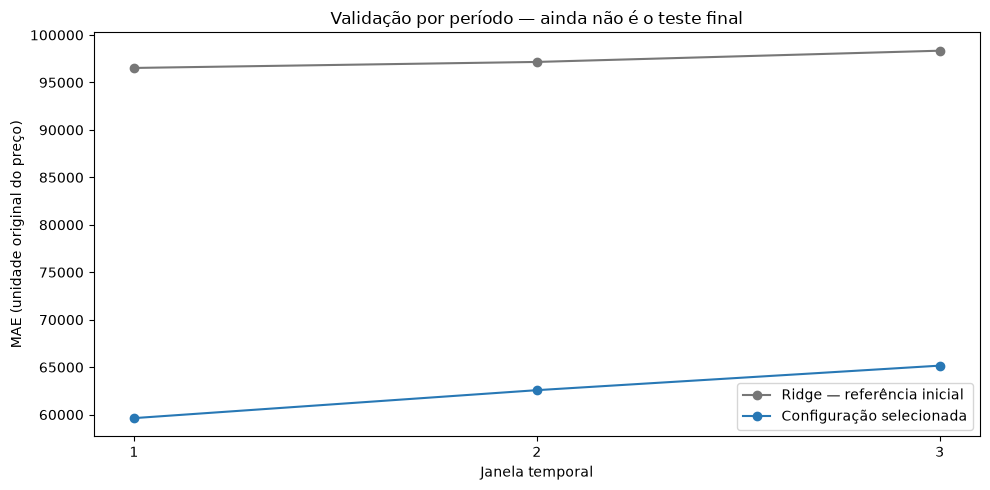

In [11]:
# Mostra a estabilidade da configuração final nas janelas originais.
%matplotlib inline
janelas_finais = pd.DataFrame(escolha_final["janelas"])
ridge_referencia = experimentos[chave_ridge]
figura, eixo = plt.subplots(figsize=(10, 5))
eixo.plot([1, 2, 3], [linha["mae"] for linha in ridge_referencia["janelas"]],
          marker="o", color="#777777", label="Ridge — referência inicial")
eixo.plot(janelas_finais["janela"], janelas_finais["mae"], marker="o",
          color="#2878B5", label="Configuração selecionada")
eixo.set_xticks([1, 2, 3])
eixo.set(xlabel="Janela temporal", ylabel="MAE (unidade original do preço)",
         title="Validação por período — ainda não é o teste final")
eixo.ticklabel_format(axis="y", style="plain")
eixo.grid(False)
eixo.legend()
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "selecao_mae_por_janela.png", dpi=150)
plt.show()

**O que o resultado mostra**

As linhas comparam a escolha final com Ridge nas mesmas vendas de validação. A configuração selecionada já foi escolhida usando essas janelas, portanto a curva não representa uma confirmação independente.

**Por que fizemos esta análise e o que decidimos**

O gráfico ajuda a examinar se o ganho médio se repete nos períodos. A etapa 06 terá a responsabilidade de avaliar o modelo congelado no teste, sem novos ajustes guiados por esse resultado.

**Resultado desta execução:** o candidato escolhido apresentou MAEs de 59.631, 62.576 e 65.162 nas janelas 1, 2 e 3, respectivamente. Ele superou o Ridge nas três, mas o erro cresceu nos períodos mais recentes. A média caiu de 97.345 no Ridge para 62.457 no candidato, redução de aproximadamente 35,84%.

**Hipótese:** diferenças no perfil dos imóveis vendidos ou no comportamento dos preços entre períodos podem contribuir para o aumento do erro. O gráfico sozinho não identifica a causa; a análise de erros por segmento na avaliação final ajudará a investigar essa possibilidade.

## 8. Congelando a configuração para a avaliação final

Vamos salvar algoritmo, parâmetros, lista e ordem das features, transformação do alvo, regras de preparação e hashes das fontes. Não ajustaremos ainda um modelo em todo o conjunto de treino e validação e não produziremos métricas de teste nesta etapa.

O notebook 06 deverá reconstruir o pipeline congelado, treinar somente nas linhas `train_validation` e avaliar uma vez nas linhas `test`. A função de criação de features e o enriquecimento demográfico continuarão fazendo parte da preparação da futura inferência.

In [12]:
# Salva configuração, previsões de validação e trilha dos experimentos.
resumo_todos = resumir(list(experimentos.values())).sort_values("mae_medio")
resumo_todos.to_csv(PASTA_RESULTADOS / "selecao_experimentos.csv", index=False)
escolha_final["previsoes"].to_csv(PASTA_RESULTADOS / "selecao_previsoes_cv.csv", index=False)
janelas_finais.to_csv(PASTA_RESULTADOS / "selecao_janelas_final.csv", index=False)
configuracoes_serializadas = [{
    "chave": chave, **configuracao,
    "metricas_janelas": experimentos[chave]["janelas"]
} for chave, configuracao in configuracoes.items()]
(PASTA_RESULTADOS / "selecao_configuracoes.json").write_text(
    json.dumps(configuracoes_serializadas, indent=2, ensure_ascii=False), encoding="utf-8"
)

colunas_escolhidas = grupos[escolha_final["grupo"]]
usa_demografia = any(coluna not in grupos["fisicas_com_derivadas"] for coluna in colunas_escolhidas)
fontes_congeladas = {
    "data/processed/features_historico.csv": PASTA_DADOS / "features_historico.csv",
    "data/processed/identificacao_alvo_historico.csv": PASTA_DADOS / "identificacao_alvo_historico.csv",
    "data/processed/contrato_features.json": PASTA_DADOS / "contrato_features.json",
    "data/processed/split_manifest.csv": PASTA_DADOS / "split_manifest.csv",
    "data/processed/cv_manifest.csv": PASTA_DADOS / "cv_manifest.csv",
}
configuracao_final = {
    "versao": "selected_candidate_v1", "status": "configuracao_congelada_aguardando_teste_final",
    "modelo": escolha_final["modelo"], "grupo": escolha_final["grupo"],
    "colunas_ordenadas": colunas_escolhidas,
    "parametros": escolha_final["parametros"], "transformacao_alvo_log1p": escolha_final["log_alvo"],
    "random_state": SEMENTE, "threads": LIMITE_THREADS,
    "pipeline": {"numeric_imputer": "median", "keep_empty_features": True,
                 "numeric_scaler": "StandardScaler" if escolha_final["modelo"] == "Ridge" else None,
                 "categorical_columns": ["zipcode"], "categorical_imputer": "constant_UNKNOWN",
                 "onehot_drop": "first", "onehot_handle_unknown": "ignore",
                 "sparse": escolha_final["modelo"] == "Ridge",
                 "boosting_early_stopping": False},
    "metricas_cv": {campo: escolha_final[campo] for campo in ["mae_medio", "mae_desvio", "rmse_medio", "r2_medio", "nao_positivas"]},
    "regra_selecao": {"metrica": "mean_fold_mae", "margem_simplicidade": MARGEM_SIMPLICIDADE,
                      "desempate": "menos_colunas_depois_menor_mae"},
    "test_evaluated": False,
    "usa_demografia": usa_demografia,
    "pendencias": ["fonte e significado das colunas originais a confirmar"] +
                  (["disponibilidade temporal dos indicadores usados precisa de confirmação antes do deploy"] if usa_demografia else []),
    "versoes": {"scikit_learn": sklearn.__version__, "optuna": optuna.__version__,
                "numpy": np.__version__, "pandas": pd.__version__},
    "source_sha256": {nome: hashlib.sha256(caminho.read_bytes()).hexdigest() for nome, caminho in fontes_congeladas.items()},
    "orcamento": {"fits_novos": contagem_ajustes, "fits_reaproveitados": 3,
                  "tentativas_optuna": len(estudo.trials), "max_tentativas_optuna": MAX_TENTATIVAS,
                  "tempo_experimentos_segundos": perf_counter() - inicio_experimentos,
                  "tempo_ajustes_segundos": segundos_ajustes,
                  "maior_rss_observado_mib": memoria_observada_mib,
                  "nota_memoria": "amostrada entre etapas, não pico exato"},
    "limitacoes": ["seleção e ajuste usam a mesma CV; avaliação final separada pendente",
                   "EDA anterior examinou todo o histórico", "busca pequena e sequencial, não exaustiva"],
}
(PASTA_ARTEFATOS / "configuracao_modelo_selecionado.json").write_text(
    json.dumps(configuracao_final, indent=2, ensure_ascii=False), encoding="utf-8"
)
exibir(pd.DataFrame({
    "item": ["Modelo", "Grupo", "Colunas", "Log do preço", "MAE de validação",
             "Ajustes novos", "Ajustes reaproveitados", "Tentativas Optuna", "Teste avaliado"],
    "valor": [escolha_final["modelo"], escolha_final["grupo"], len(colunas_escolhidas), escolha_final["log_alvo"],
              round(escolha_final["mae_medio"], 2), contagem_ajustes, 3, len(estudo.trials), False],
}))

,item,valor
0,Modelo,HistGradientBoosting
1,Grupo,fisicas_demografia_sem_hous_val_amt
2,Colunas,50
3,Log do preço,True
4,MAE de validação,62456.58
5,Ajustes novos,48
6,Ajustes reaproveitados,3
7,Tentativas Optuna,8
8,Teste avaliado,False


**O que o resultado mostra**

A saída identifica uma configuração congelada, não um modelo de produção já validado. Foram salvos os parâmetros e as previsões de validação para rastrear a decisão.

**Por que fizemos esta análise e o que decidimos**

A escolha pode ser mantida mesmo que Optuna não melhore o resultado anterior. Se utilizar demografia, sua disponibilidade temporal continua sendo uma pendência material antes da implantação. O teste não foi usado para escolher modelos ou aumentar a busca.

**Resultado desta execução:** foram realizados 48 ajustes novos e reaproveitados três do notebook 04. Os experimentos levaram aproximadamente 115 segundos, dos quais 112 foram gastos em ajuste e previsão. A maior memória do processo observada entre etapas foi de aproximadamente 284 MiB; esse número não é o pico exato nem inclui o consumo dos demais programas.

A configuração congelada usa HistGradientBoosting, 50 colunas e logaritmo do preço. Seu MAE médio de validação é 62.457, RMSE médio 112.161 e R² médio 0,899. O R² não significa “89,9% de acerto”. Nenhuma previsão de validação foi não positiva. Como a demografia foi escolhida, precisamos confirmar sua disponibilidade histórica antes de apresentar o pipeline como pronto para implantação.

## Conclusão para stakeholders

Selecionamos **HistGradientBoosting com 50 entradas e transformação logarítmica do preço**. Nas três janelas de validação, o erro absoluto médio caiu de aproximadamente **97.345 no Ridge para 62.457**, redução de **35,84%**. Essa redução compara a configuração final com a referência física inicial e combina o efeito do algoritmo, das entradas e dos parâmetros.

Investigamos as hipóteses comparando grupos de variáveis nos mesmos períodos. As derivadas tiveram efeito pequeno e dependente do modelo; a demografia acrescentou ganho nos dois candidatos avaliados. `hous_val_amt` não melhorou o boosting nesta comparação e ficou fora da configuração selecionada. Isso não comprova a origem nem a disponibilidade temporal dos indicadores utilizados.

Os experimentos consumiram cerca de dois minutos nesta execução, com até duas threads. Os resultados estão salvos, acompanhados de parâmetros e ordem das colunas. Se os dados, as versões ou as configurações mudarem, estes números deverão ser revistos.

O próximo passo é treinar a configuração congelada no conjunto de treino e validação e avaliá-la no **notebook 06**, usando o teste reservado. Ainda não temos a métrica final de generalização. Não reajustaremos o modelo em resposta ao teste para depois apresentar o mesmo teste como independente.

**Como explicar na entrevista:** “Comparei quatro algoritmos nas mesmas janelas temporais. Nos dois melhores, testei o efeito dos grupos de variáveis; depois avaliei a transformação do preço e uma busca pequena com Optuna. Escolhi pela média do MAE, com preferência por menos colunas quando o desempenho era próximo. Registrei os resultados e congelei a configuração antes da avaliação final, mantendo explícitas as limitações dos dados demográficos.”